In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [34]:
train = pd.read_csv("/kaggle/input/datasets/dillsunnyb11/digit-recognizer/train.csv")
test = pd.read_csv("/kaggle/input/datasets/dillsunnyb11/digit-recognizer/test.csv")
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
train.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
23568,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


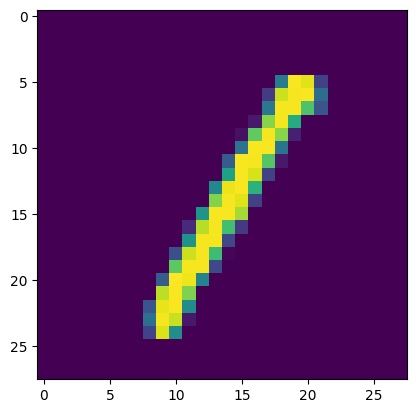

In [40]:
plt.imshow(train.iloc[23568, 1:].values.astype(float).reshape(28, 28))

In [37]:
test.sample()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
18445,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


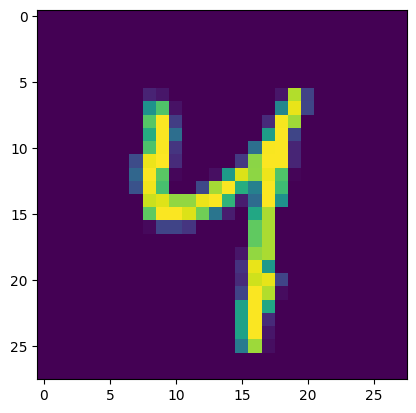

In [42]:
plt.imshow(test.iloc[18445,:].values.astype(float).reshape(28, 28))

In [46]:
X = train.iloc[:, 1:]
y = train.iloc[:, 1]

X.shape, y.shape

((42000, 784), (42000,))

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((37800, 784), (4200, 784), (37800,), (4200,))

In [50]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

In [51]:
pca = PCA(n_components=None)
X_train = pca.fit_transform(X_train)
X_test = pca.fit_transform(X_test)

In [53]:
pca.explained_variance_

array([3.35501646e+05, 2.49360325e+05, 2.02925024e+05, 1.86767126e+05,
       1.69180430e+05, 1.46389902e+05, 1.11739711e+05, 1.03626944e+05,
       9.47644162e+04, 8.41707875e+04, 7.41018728e+04, 7.21561759e+04,
       5.94750877e+04, 5.73531415e+04, 5.45455755e+04, 5.16877325e+04,
       4.50774133e+04, 4.41935483e+04, 4.17016969e+04, 3.92422320e+04,
       3.58836313e+04, 3.41100659e+04, 3.26278742e+04, 3.12133681e+04,
       3.07528407e+04, 2.98218772e+04, 2.74092006e+04, 2.71576062e+04,
       2.53070894e+04, 2.34349458e+04, 2.27184593e+04, 2.23052584e+04,
       2.08373248e+04, 2.04844482e+04, 1.92600256e+04, 1.88018956e+04,
       1.76178914e+04, 1.67838691e+04, 1.65280699e+04, 1.62737569e+04,
       1.54298949e+04, 1.49591349e+04, 1.45928144e+04, 1.42815366e+04,
       1.36380417e+04, 1.32075814e+04, 1.25622324e+04, 1.23294913e+04,
       1.18290148e+04, 1.13209010e+04, 1.11444027e+04, 1.06691028e+04,
       1.02951684e+04, 1.02198971e+04, 9.89229718e+03, 9.34687759e+03,
      

In [55]:
pca.explained_variance_.shape

(784,)

In [56]:
pca.components_.shape

(784, 784)

In [57]:
pca.explained_variance_ratio_

array([9.75470301e-02, 7.25014598e-02, 5.90004062e-02, 5.43025008e-02,
       4.91891730e-02, 4.25628320e-02, 3.24882963e-02, 3.01295112e-02,
       2.75527332e-02, 2.44726380e-02, 2.15451033e-02, 2.09793923e-02,
       1.72923687e-02, 1.66754133e-02, 1.58591141e-02, 1.50281969e-02,
       1.31062480e-02, 1.28492645e-02, 1.21247592e-02, 1.14096704e-02,
       1.04331579e-02, 9.91749418e-03, 9.48654726e-03, 9.07527994e-03,
       8.94138169e-03, 8.67070426e-03, 7.96921906e-03, 7.89606804e-03,
       7.35803068e-03, 6.81370536e-03, 6.60538705e-03, 6.48524900e-03,
       6.05844762e-03, 5.95584882e-03, 5.59984823e-03, 5.46664702e-03,
       5.12239806e-03, 4.87990628e-03, 4.80553271e-03, 4.73159124e-03,
       4.48623855e-03, 4.34936518e-03, 4.24285759e-03, 4.15235365e-03,
       3.96525763e-03, 3.84010140e-03, 3.65246630e-03, 3.58479690e-03,
       3.43928345e-03, 3.29154948e-03, 3.24023264e-03, 3.10203929e-03,
       2.99331796e-03, 2.97143283e-03, 2.87618324e-03, 2.71760261e-03,
      

In [58]:
# use cumulative sum to find the optimal pca components

np.cumsum(pca.explained_variance_ratio_)

array([0.09754703, 0.17004849, 0.2290489 , 0.2833514 , 0.33254057,
       0.3751034 , 0.4075917 , 0.43772121, 0.46527394, 0.48974658,
       0.51129168, 0.53227108, 0.54956344, 0.56623886, 0.58209797,
       0.59712617, 0.61023242, 0.62308168, 0.63520644, 0.64661611,
       0.65704927, 0.66696676, 0.67645331, 0.68552859, 0.69446997,
       0.70314068, 0.7111099 , 0.71900596, 0.72636399, 0.7331777 ,
       0.73978309, 0.74626834, 0.75232678, 0.75828263, 0.76388248,
       0.76934913, 0.77447153, 0.77935143, 0.78415696, 0.78888856,
       0.79337479, 0.79772416, 0.80196702, 0.80611937, 0.81008463,
       0.81392473, 0.8175772 , 0.82116199, 0.82460128, 0.82789283,
       0.83113306, 0.8342351 , 0.83722842, 0.84019985, 0.84307603,
       0.84579363, 0.84845136, 0.85102748, 0.85352714, 0.85599442,
       0.85839608, 0.86076802, 0.86312699, 0.8653177 , 0.86743801,
       0.86954707, 0.87160474, 0.87356879, 0.87549179, 0.87740925,
       0.87927642, 0.88111919, 0.88289037, 0.88460976, 0.88627

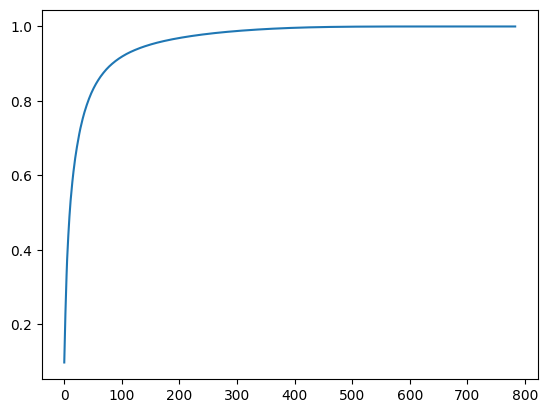

In [59]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

# get up to 90%, it is all you need